In [1]:
print("Hello, World!")

Hello, World!


In [1]:
from dotenv import load_dotenv
import os

load_dotenv("config.env")


assert os.getenv("TAVILY_API_KEY")

assert os.getenv("COHERE_API_KEY")

In [2]:
print(os.getenv("COHERE_API_KEY"))

cohere_uHGYkabUIohqDwo9JhaatUfLygvTLDgdMtFQWUod4SoLfY


In [3]:
from langchain_cohere import ChatCohere

llm = ChatCohere(
    model="command-nightly",
    temperature=0.3,
)

In [4]:
response = llm.invoke("Explain LangGraph in one sentence.")

print(response.content)

LangGraph is a framework designed to build and manage complex, stateful language model applications by orchestrating the flow of data and logic through modular components, enabling scalable and maintainable AI workflows.


In [5]:
from langchain_community.tools import TavilySearchResults
tool = TavilySearchResults(max_results=5)

result = tool.invoke("Who won the FIFA World Cup 2022?")

print(result)

/tmp/ipykernel_22358/2832692242.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import TavilySearchResults
/tmp/ipykernel_22358/2832692242.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=5)


[{'title': 'Who won the last FIFA World Cup? How Lionel Messi led his team to victory in 2022 | cbs8.com', 'url': 'https://www.cbs8.com/article/sports/soccer/world-cup/lionel-messi-argentina-fifa-world-cup-2022-champion/507-d51d563c-498d-4f0c-a201-05b787bf9ae8', 'content': '### Who won the last World Cup?\n\nArgentina won the 2022 FIFA World Cup in Qatar, defeating France in a final widely considered one of the most dramatic in the tournament’s history. The two teams were level 3-3 after 120 minutes of play before Argentina won 4-2 in a penalty shootout on Dec. 18, 2022.\n\nLionel Messi, widely regarded as the greatest soccer player of his generation, scored twice in the final and was named the tournament’s best player. The victory was a milestone moment for Messi, who had won nearly every major individual award in the sport but never a World Cup. He was 35 at the time and had indicated Qatar would be his final tournament. [...] x\n\nSkip Navigation\n\n Share on Facebook\n Share on SMS

In [40]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

response = llm.invoke("Say Hello")

print(response.content)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [6]:
from typing import TypedDict


class HealthState(TypedDict):
    topic: str
    search_results: str
    summary: str
    quiz_question: str
    answer: str
    user_answer: str
    feedback: str
    continue_chat: str

In [7]:
from langchain_community.tools.tavily_search import TavilySearchResults

search_tool = TavilySearchResults(max_results=5)

def ask_topic(state):
    topic = input("Enter a health topic: ")

    return {
        "topic": topic
    }


def tavily_search(state):
    results = search_tool.invoke(state["topic"])

    return {
        "search_results": results
    }

In [8]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(HealthState)

builder.add_node("ask_topic", ask_topic)
builder.add_node("tavily_search", tavily_search)

builder.add_edge(START, "ask_topic")
builder.add_edge("ask_topic", "tavily_search")
builder.add_edge("tavily_search", END)

graph = builder.compile()

In [ ]:

result = graph.invoke({})

#print("\nTopic:")
#print(result["topic"])

#print("\nSearch Results:")
#print(result["search_results"])


Topic:
cancer

Search Results:
[{'title': 'Updating the Definition of Cancer - PMC', 'url': 'https://pmc.ncbi.nlm.nih.gov/articles/PMC10618731', 'content': "Most definitions of cancer broadly conform to the current NCI definition: “Cancer is a disease in which some of the body's cells grow uncontrollably and spread to other parts of the body.” These definitions tend to describe what cancer “looks like” or “does” but do not describe what cancer “is” or “has become.” While reflecting past insights, current definitions have not kept pace with the understanding that the cancer cell is itself transformed and evolving. We propose a revised definition of cancer: Cancer is a disease of uncontrolled proliferation by transformed cells subject to evolution by natural selection. We believe this definition captures the essence of the majority of previous and current definitions. To the simplest definition of cancer as a disease of uncontrolled [...] | A group of diseases in which cells in the body

In [9]:
def summarize(state):

    prompt = f"""
    You are a helpful medical assistant.

    Summarize the following medical information in simple,
    patient-friendly language.

    Include:
    - What it is
    - Symptoms
    - Causes
    - Treatment
    - Prevention

    Search Results:
    {state["search_results"]}
    """

    response = llm.invoke(prompt)

    return {
        "summary": response.content
    }

In [10]:
def display_summary(state):

    print("\n" + "="*60)
    print("MEDICAL SUMMARY")
    print("="*60)

    print(state["summary"])

    print("="*60)

    return {}

In [11]:
def ready_check(state):

    ready = input("\nType 'yes' when you are ready for the quiz: ")

    return {
        "ready": ready
    }

In [12]:
builder.add_node("summarize", summarize)
builder.add_node("display_summary", display_summary)
builder.add_node("ready_check", ready_check)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [13]:
builder.add_edge("tavily_search", "summarize")
builder.add_edge("summarize", "display_summary")
builder.add_edge("display_summary", "ready_check")
builder.add_edge("ready_check", END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [21]:
graph = builder.compile()

In [ ]:
result = graph.invoke({})

#print(result["summary"])
#print(result["ready"])


MEDICAL SUMMARY
Here's a summary of the medical information about cancer in patient-friendly language:

### What is Cancer?

Cancer is a group of diseases where some of your body's cells start to grow and multiply in an uncontrolled way. Normally, cells grow, divide, and die in an orderly fashion, but cancer cells ignore these signals. These abnormal cells can form a lump or mass called a **tumor**, though some cancers, like leukemia, don't form solid tumors. A key feature of cancer is its ability to invade nearby tissues and spread to other parts of the body through the bloodstream or lymphatic system. This spreading process is called **metastasis**, and it's often the main reason cancer becomes life-threatening. There are over 100 different types of cancer, as it can start almost anywhere in the body.

### What are the Symptoms?

The provided information does not list specific symptoms of cancer. Symptoms can vary widely depending on the type of cancer and where it is located in the

KeyError: 'ready'

In [14]:
def generate_quiz(state):

    prompt = f"""
    You are a medical educator.

    Based on the summary below, generate ONE simple
    comprehension question for the patient.

    Summary:
    {state["summary"]}

    Return only the question.
    """

    response = llm.invoke(prompt)

    return {
        "quiz_question": response.content
    }

In [15]:
def ask_quiz(state):

    print("\n" + "="*60)
    print("QUIZ")
    print("="*60)

    print(state["quiz_question"])

    print("="*60)

    return {}

In [16]:
def receive_answer(state):

    answer = input("\nEnter your answer: ")

    return {
        "user_answer": answer
    }

In [17]:
builder.add_node("generate_quiz", generate_quiz)
builder.add_node("ask_quiz", ask_quiz)
builder.add_node("receive_answer", receive_answer)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [18]:
builder.add_edge("ready_check", "generate_quiz")
builder.add_edge("generate_quiz", "ask_quiz")
builder.add_edge("ask_quiz", "receive_answer")
builder.add_edge("receive_answer", END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [19]:
def grade_answer(state):

    prompt = f"""
        You are a medical instructor.

        Summary:
        {state["summary"]}

        Question:
        {state["quiz_question"]}

        Patient's Answer:
        {state["user_answer"]}

        Evaluate the patient's answer.

        Return in this format:

        Grade: Correct / Partially Correct / Incorrect

        Explanation:
        Explain why.

        Citation:
        Mention the relevant part of the summary.
    """

    response = llm.invoke(prompt)

    return {
        "feedback": response.content
    }

In [20]:
def display_feedback(state):

    print("\n" + "="*60)
    print("QUIZ RESULT")
    print("="*60)

    print(state["feedback"])

    print("="*60)

    return {}

In [21]:
def continue_or_exit(state):

    choice = input(
        "\nWould you like to learn another topic? (yes/no): "
    ).strip().lower()

    return {
        "continue_chat": choice
    }

In [22]:
from IPython.display import clear_output

def reset_state(state):

    clear_output(wait=True)

    return {
        "topic": "",
        "search_results": [],
        "summary": "",
        "ready": "",
        "quiz_question": "",
        "user_answer": "",
        "feedback": "",
        "continue_chat": ""
    }

In [23]:

def route(state):

    if state["continue_chat"] == "yes":
        return "reset"

    return END

In [24]:
builder.add_conditional_edges(
    "continue",
    route,
    {
        "reset": "reset",
        END: END
    }
)

builder.add_edge("reset", "ask_topic")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [25]:
builder.add_node("grade", grade_answer)
builder.add_node("feedback", display_feedback)
builder.add_node("continue", continue_or_exit)
builder.add_node("reset", reset_state)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [26]:
builder.add_edge("receive_answer", "grade")
builder.add_edge("grade", "feedback")
builder.add_edge("feedback", "continue")
builder.add_edge("continue", "reset")
builder.add_edge("reset", END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [27]:
graph = builder.compile()

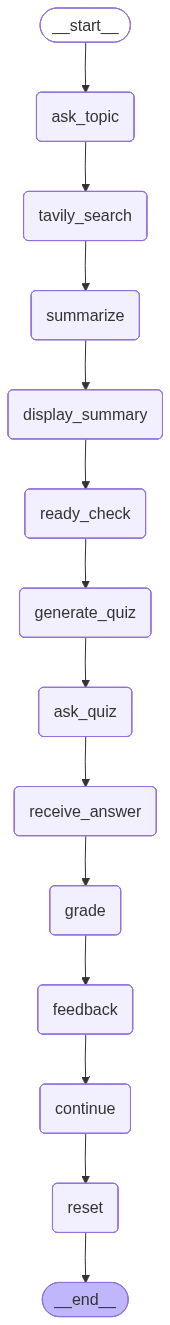

In [ ]:
from IPython.display import Image, display

display(
    Image(graph.get_graph().draw_mermaid_png())
)

In [ ]:
result = graph.invoke({})

print("\nTopic:")
print(result["topic"])
print("\nSearch Results:")
print(result["search_results"])
print("\nSummary:")
print(result["summary"])
print("\nQuiz Question:")
print(result["quiz_question"])
print("\nAnswer:")
print(result["answer"])
print("\nGrade:")
print(result["grade"])
print("\nFeedback:")
print(result["feedback"])
print("\nContinue Chat:")
print(result["continue_chat"])


MEDICAL SUMMARY
It seems there was a misunderstanding in your request. The search results you provided are not related to medical information but rather to the definition and usage of the word "No," including its grammatical roles and a song by Meghan Trainor. Since there is no medical information to summarize, I’ll provide a general outline of how I would approach summarizing medical information if it were available:

### Medical Information Summary Template:

**What it is:**  
[Brief description of the medical condition or topic.]

**Symptoms:**  
[Common signs or symptoms associated with the condition.]

**Causes:**  
[Underlying reasons or factors contributing to the condition.]

**Treatment:**  
[Available treatment options, including medications, therapies, or lifestyle changes.]

**Prevention:**  
[Steps or measures to reduce the risk of developing the condition.]

If you have specific medical information you'd like summarized, please provide it, and I’ll be happy to assist!

Q

In [ ]:
png = graph.get_graph().draw_mermaid_png()

with open("healthbot_graph.png", "wb") as f:
    f.write(png)